# CMAPSS FD001 — Preprocessing & Feature Engineering

## Objectives

- remove low-information sensors
- normalize sensor measurements
- create rolling statistics
- generate lag-based temporal features
- prepare dataset for predictive modeling

## Environment and Library Setup

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
import os

import joblib
import sys
sys.path.append("..")
from src.preprocessing import normalize_sensors, add_rolling_stats, add_lag_features, build_final_dataset, split_datasets

## Load data

In [60]:
df = pd.read_parquet("../data/interim/train_fd001_eda.parquet")
df.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_21,life_pct,life_pct_bin,sensor_2_norm,sensor_7_norm,sensor_11_norm,sensor_12_norm,max_cycle,RUL,life_phase
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,23.4190,0.005208,"(0.00177, 0.0526]",0.044,0.859155,0.338462,0.639640,192,191,early
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,23.4236,0.010417,"(0.00177, 0.0526]",0.176,0.715962,0.353846,0.825826,192,190,early
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,23.3442,0.015625,"(0.00177, 0.0526]",0.256,0.835681,0.184615,0.867868,192,189,early
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,23.3739,0.020833,"(0.00177, 0.0526]",0.256,0.880282,0.076923,1.000000,192,188,early
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,23.4044,0.026042,"(0.00177, 0.0526]",0.264,0.774648,0.192308,0.798799,192,187,early


In [61]:
cols_to_drop = ["life_pct", "life_pct_bin", "max_cycle", "life_phase"] + \
               [c for c in df.columns if c.endswith("_norm")]
df = df.drop(columns=cols_to_drop, errors="ignore")

## Sensors selection

In the previous notebook (EDA), we analyzed all 21 sensors across two dimensions:
- **Variance**: sensors with near-zero variance (< 1e-2) cannot encode degradation trends and are considered uninformative
- **Correlation with RUL**: computed per engine and averaged, to avoid bias introduced by engines with different lifetimes

A sensor is removed only if it satisfies **both** conditions simultaneously —
low variance alone is insufficient if the sensor carries a meaningful correlation signal with RUL.

The resulting selection is loaded here and applied directly, ensuring consistency between the exploratory and preprocessing stages.

In [62]:
selected_sensors = joblib.load('../outputs/selected_sensors.pkl')
print(selected_sensors)

['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [63]:
sensor_cols_to_remove = [col for col in df.columns if "sensor" in col and col not in selected_sensors]
df = df.drop(columns=sensor_cols_to_remove)

Top sensors are automatically selected based on absolute correlation with RUL.

## RUL Cap

Cap RUL at 125 cycles — values above this threshold are less informative for maintenance decisions, as the engine is far from failure.  
This focuses the model on the critical degradation window.  
Rationale defined in notebook 01 (EDA).

In [64]:
df_raw = df.copy()

In [65]:
RUL_CAP = 125
df["RUL"] = df["RUL"].clip(upper=RUL_CAP)

print(f"RUL capped at {RUL_CAP} cycles")
print(f"RUL range after cap: {df['RUL'].min()} – {df['RUL'].max()}")

RUL capped at 125 cycles
RUL range after cap: 0 – 125


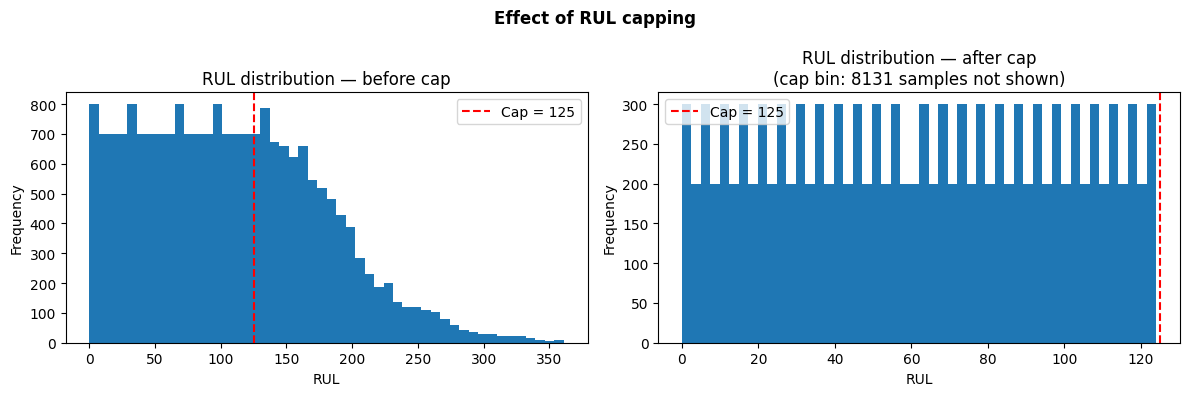

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pre-cap
axes[0].hist(df_raw["RUL"], bins=50)
axes[0].axvline(RUL_CAP, color='red', linestyle='--', label=f'Cap = {RUL_CAP}')
axes[0].set_title("RUL distribution — before cap")
axes[0].set_xlabel("RUL")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Post-cap
axes[1].hist(df[df["RUL"] < RUL_CAP]["RUL"], bins=50)
axes[1].axvline(RUL_CAP, color='red', linestyle='--', label=f'Cap = {RUL_CAP}')
cap_count = (df["RUL"] == RUL_CAP).sum()
axes[1].set_title(f"RUL distribution — after cap\n(cap bin: {cap_count} samples not shown)")
axes[1].set_xlabel("RUL")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.suptitle("Effect of RUL capping", fontweight="bold")
plt.tight_layout()
plt.show()

**Observations:**
- Before capping, RUL is right-skewed with values up to 361 cycles
- After capping, 8131 samples are collapsed to 125 — roughly 40% of the training set was in the high-RUL region
- The distribution below 125 is approximately uniform, confirming that the dataset covers the full degradation window evenly
- The cap focuses the model on the actionable maintenance range

## Train-Validation split

The dataset is split into three distinct sets, each designed
for a specific downstream task:

- **RUL Forecasting**: 80/20 split by `engine_id` — engines are independent units
- **Forecasting**: 80/20 temporal split per engine — predict future sensor values
- **Anomaly Detection**: healthy vs degraded split — train on early cycles only,
  test on degraded behavior (RUL < threshold)

Splitting is performed on raw data before normalization to prevent
data leakage — the scaler is fitted exclusively on the RUL
training set and applied to all other splits.

In [67]:
splits_raw = split_datasets(df, rul_threshold=125, temporal_ratio=0.8, random_seed=42)

## Sensor normalization

Sensor measurements span very different physical scales.  
Without normalization, high-magnitude features dominate distance-based models and gradient-based optimizers.

We apply Z-score standardization (zero mean, unit variance) via
`StandardScaler`, fitted exclusively on the RUL training set and
applied to all other splits to prevent data leakage.

In [68]:
# Normalize each split separately
# RUL
df_rul_train, scaler = normalize_sensors(splits_raw["rul"][0])
df_rul_val, _ = normalize_sensors(splits_raw["rul"][1], scaler=scaler)

# Forecasting
df_forecast_train, _ = normalize_sensors(splits_raw["forecast"][0], scaler=scaler)
df_forecast_val, _ = normalize_sensors(splits_raw["forecast"][1], scaler=scaler)

# Anomaly
df_anomaly_train, _ = normalize_sensors(splits_raw["anomaly"][0], scaler=scaler)
df_anomaly_val, _ = normalize_sensors(splits_raw["anomaly"][1], scaler=scaler)

In [69]:
joblib.dump(scaler, '../outputs/scaler.pkl')

['../outputs/scaler.pkl']

## Rolling window features

Sensor signals in turbofan engines are noisy due to measurement noise and short-term operational fluctuations.

Rolling statistics help by:
- **Rolling mean**: smooths the signal, making gradual degradation trends more visible.
- **Rolling std**: captures local volatility, which can increase as components degrade.

We use a window of **5 cycles**, computed per engine (`groupby "engine_id")`) to avoid mixing signals across different units.

> The first `window_size - 1` rows per engine will produce NaN values and will need to be handled downstream (e.g., via `dropna()` or forward-fill).

In [70]:
# Add rolling statistics to each split separately
#RUL
df_rul_train = add_rolling_stats(df_rul_train, sensor_cols=selected_sensors, window_size=5)
df_rul_val = add_rolling_stats(df_rul_val, sensor_cols=selected_sensors, window_size=5)

# Forecast
df_forecast_train = add_rolling_stats(df_forecast_train, sensor_cols=selected_sensors, window_size=5)
df_forecast_val = add_rolling_stats(df_forecast_val, sensor_cols=selected_sensors, window_size=5)

# Anomaly
df_anomaly_train = add_rolling_stats(df_anomaly_train, sensor_cols=selected_sensors, window_size=5)
df_anomaly_val = add_rolling_stats(df_anomaly_val, sensor_cols=selected_sensors, window_size=5)

In [71]:
df_rul_train.filter(regex="rolling").head()

,sensor_2_rolling_mean,sensor_2_rolling_std,sensor_3_rolling_mean,sensor_3_rolling_std,sensor_4_rolling_mean,sensor_4_rolling_std,sensor_7_rolling_mean,sensor_7_rolling_std,sensor_9_rolling_mean,sensor_9_rolling_std,...,sensor_14_rolling_mean,sensor_14_rolling_std,sensor_15_rolling_mean,sensor_15_rolling_std,sensor_17_rolling_mean,sensor_17_rolling_std,sensor_20_rolling_mean,sensor_20_rolling_std,sensor_21_rolling_mean,sensor_21_rolling_std
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-0.962271,0.470368,-0.587343,0.66698,-0.65205,0.240463,0.915702,0.324113,-0.734504,0.203918,...,-0.528169,0.136454,-0.78724,0.693938,-0.927827,0.708459,0.800671,0.408342,0.969167,0.30942


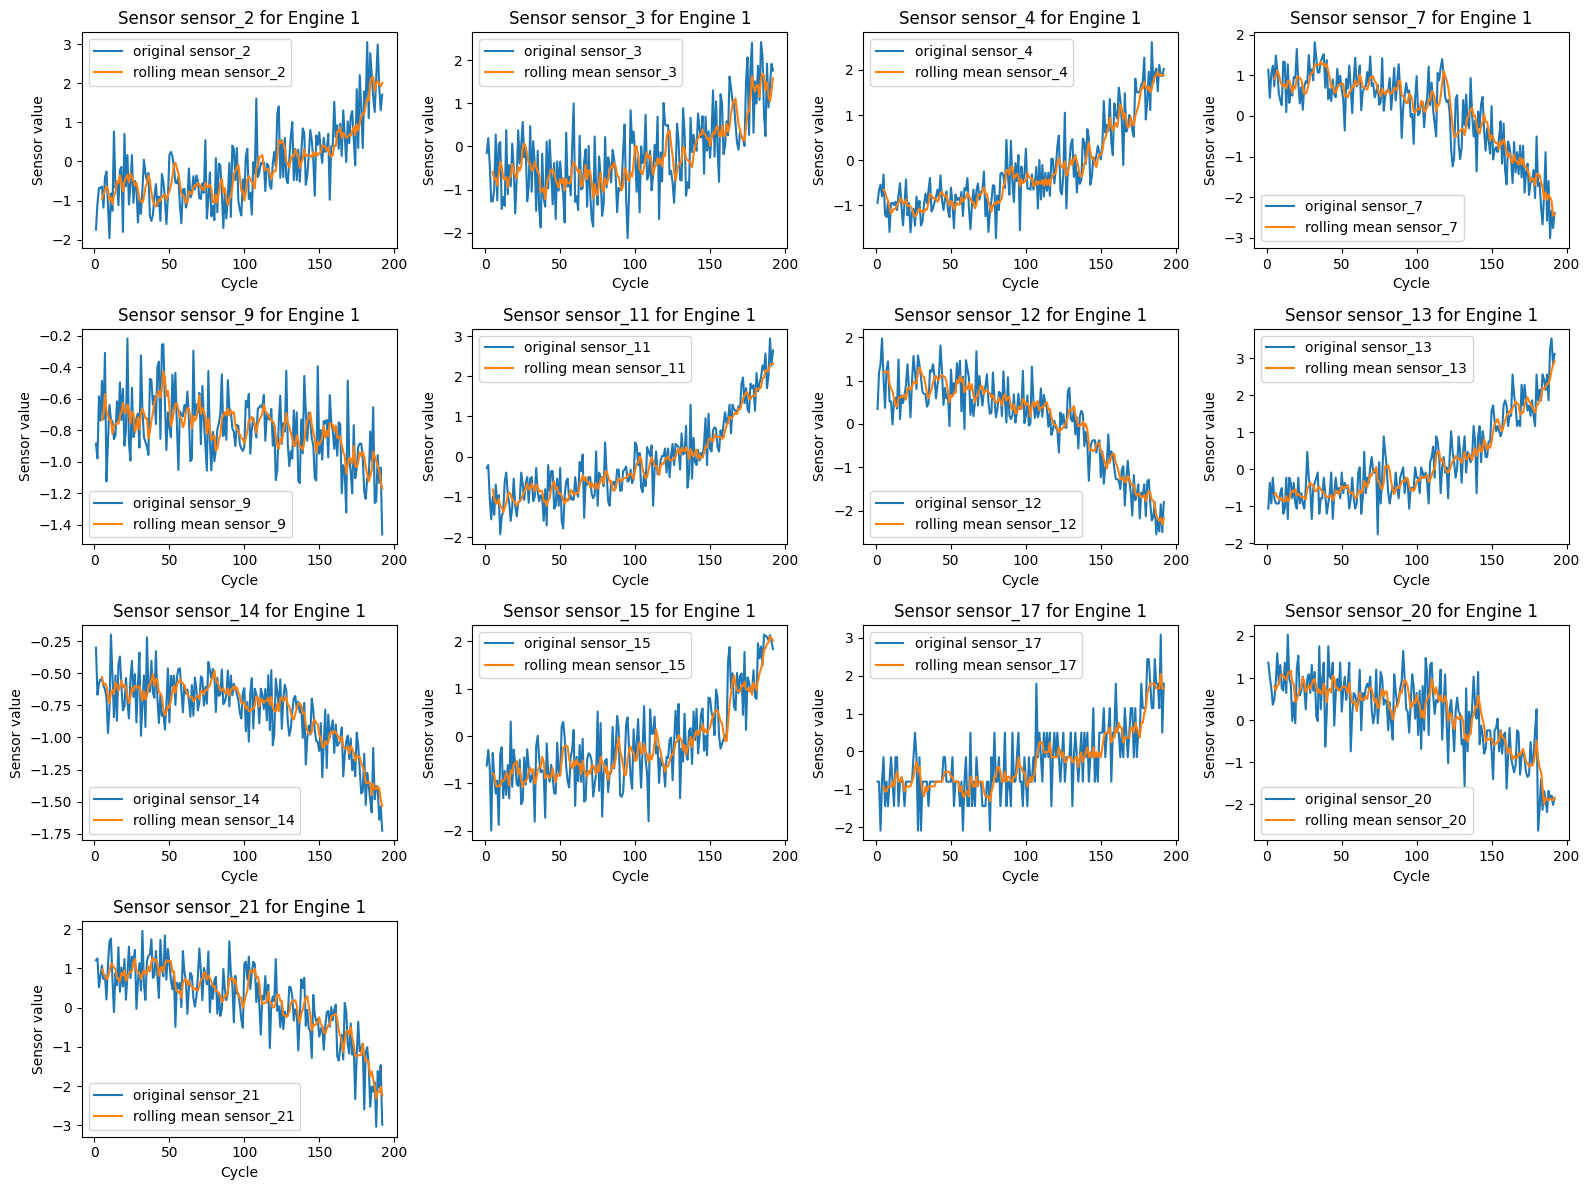

In [72]:
engine = 1
subset = df_rul_train[df_rul_train["engine_id"] == engine]

num_sensors = len(selected_sensors)
# Determine a suitable grid size
num_cols = min(4, num_sensors)
num_rows = (num_sensors + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(4 * num_cols, 3 * num_rows))
axes = axes.flatten()

for i, sensor_to_plot in enumerate(selected_sensors):
    ax = axes[i]

    ax.plot(subset["cycle"],
            subset[sensor_to_plot],
            label=f"original {sensor_to_plot}",
            alpha=1)

    if f'{sensor_to_plot}_rolling_mean' in subset.columns:
        ax.plot(subset["cycle"],
                subset[f'{sensor_to_plot}_rolling_mean'],
                label=f"rolling mean {sensor_to_plot}")

    ax.legend()
    ax.set_title(f"Sensor {sensor_to_plot} for Engine {engine}")
    ax.set_xlabel("Cycle")
    ax.set_ylabel("Sensor value")


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Observations:**
- Rolling mean smooths short-term noise while preserving the
  underlying degradation trend
- Rolling std captures local volatility, which increases as
  components approach failure
- NaN values introduced by the first window_size - 1 cycles
  are handled in the final feature selection step

## Lag features

Lag features capture the recent history of each sensor by shifting its values back by k cycles. This allows the model to infer the direction and rate of change of the degradation process.

We apply lags of 1, 2 and 3 cycles on the same top 5 sensors used for rolling statistics, keeping the feature set consistent and interpretable.

> The first k rows per engine will produce NaN values, handled downstream together with those introduced by the rolling window step.

In [73]:
# Add lag features to each split separately
# RUL
df_rul_train = add_lag_features(df_rul_train, sensor_cols=selected_sensors, lag_steps=[1, 2, 3])
df_rul_val = add_lag_features(df_rul_val, sensor_cols=selected_sensors, lag_steps=[1, 2, 3])

# Forecast
df_forecast_train = add_lag_features(df_forecast_train, sensor_cols=selected_sensors, lag_steps=[1, 2, 3])
df_forecast_val = add_lag_features(df_forecast_val, sensor_cols=selected_sensors, lag_steps=[1, 2, 3])

# Anomaly
df_anomaly_train = add_lag_features(df_anomaly_train, sensor_cols=selected_sensors, lag_steps=[1, 2, 3])
df_anomaly_val = add_lag_features(df_anomaly_val, sensor_cols=selected_sensors, lag_steps=[1, 2, 3])

In [74]:
df_rul_train.filter(regex="lag").head()

,sensor_2_lag_1,sensor_2_lag_2,sensor_2_lag_3,sensor_3_lag_1,sensor_3_lag_2,sensor_3_lag_3,sensor_4_lag_1,sensor_4_lag_2,sensor_4_lag_3,sensor_7_lag_1,...,sensor_15_lag_3,sensor_17_lag_1,sensor_17_lag_2,sensor_17_lag_3,sensor_20_lag_1,sensor_20_lag_2,sensor_20_lag_3,sensor_21_lag_1,sensor_21_lag_2,sensor_21_lag_3
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-1.739618,NaN,NaN,-0.150401,NaN,NaN,-0.942239,NaN,NaN,1.137640,...,NaN,-0.798481,NaN,NaN,1.366421,NaN,NaN,1.209141,NaN,NaN
2,-1.078473,-1.739618,NaN,0.196535,-0.150401,NaN,-0.659399,-0.942239,NaN,0.446915,...,NaN,-0.798481,-0.798481,NaN,1.033627,1.366421,NaN,1.251630,1.209141,NaN
3,-0.677779,-1.078473,-1.739618,-0.430241,0.196535,-0.150401,-0.541364,-0.659399,-0.942239,1.024407,...,-0.622530,-2.091945,-0.798481,-0.798481,0.756299,1.033627,1.366421,0.518224,1.251630,1.209141
4,-0.677779,-0.677779,-1.078473,-1.281214,-0.430241,0.196535,-0.800819,-0.541364,-0.659399,1.239551,...,-0.293645,-0.798481,-2.091945,-0.798481,0.368039,0.756299,1.033627,0.792559,0.518224,1.251630


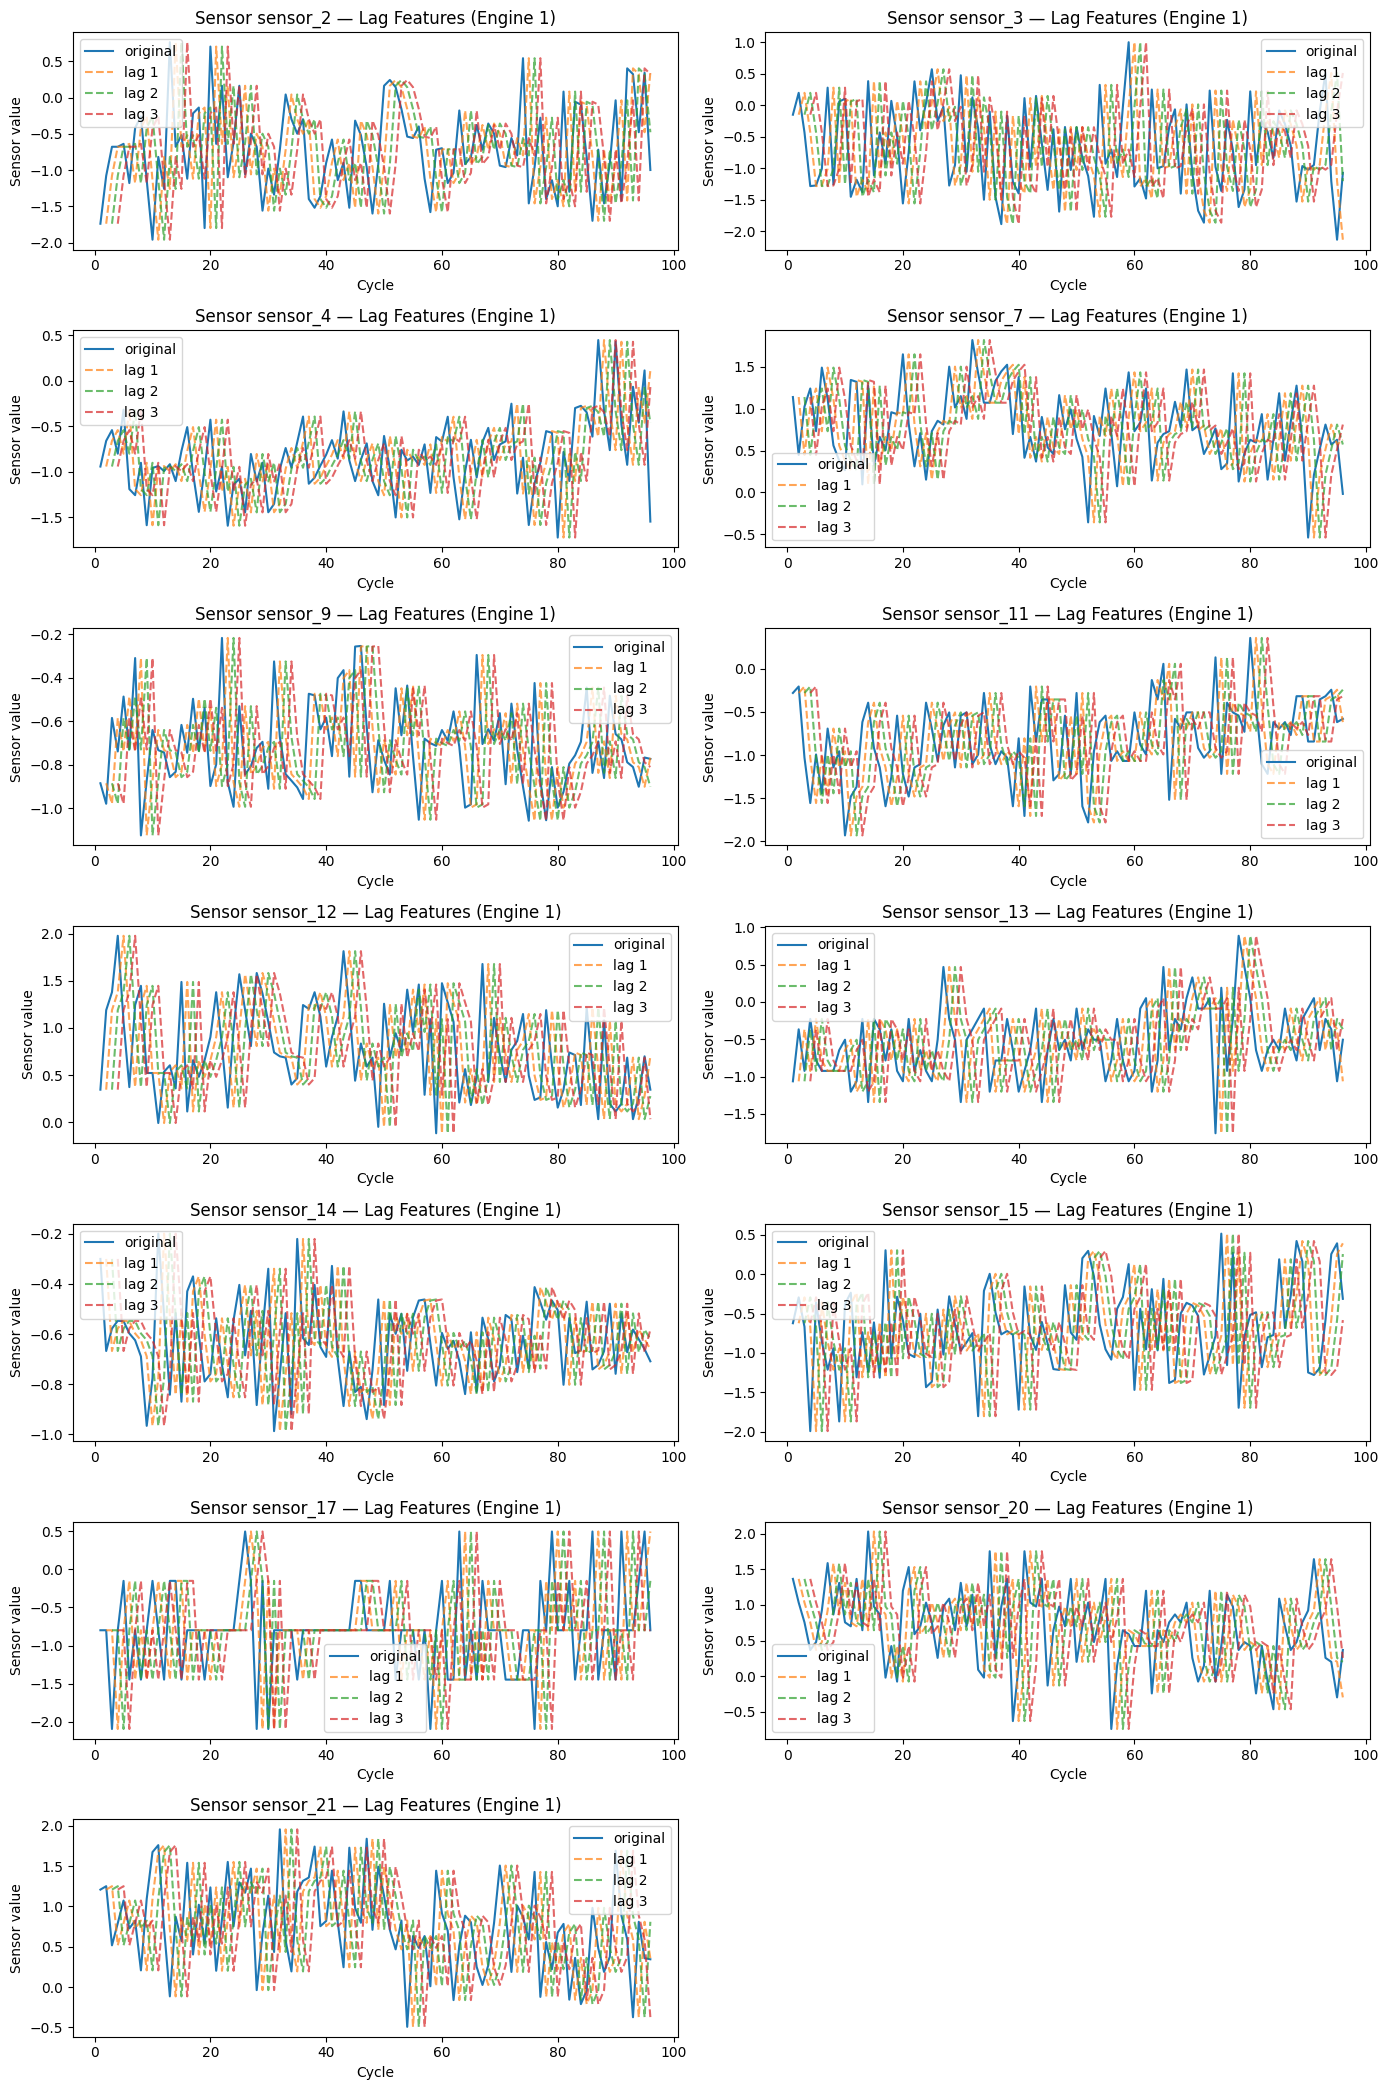

In [75]:
engine = 1
subset = df_rul_train[df_rul_train["engine_id"] == engine]
subset = subset[subset["cycle"] <= subset["cycle"].max() * 0.5]
lag_steps = [1, 2, 3]

n_cols = 2
n_rows = (len(selected_sensors) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7*n_cols, 3 * n_rows))
axes = axes.flatten()

for i, sensor in enumerate(selected_sensors):
    ax = axes[i]
    ax.plot(subset["cycle"],
            subset[sensor],
            label="original")

    for lag in lag_steps:
        ax.plot(subset["cycle"],
                subset[f"{sensor}_lag_{lag}"],
                label=f"lag {lag}",
                alpha=0.7,
                linestyle="--")

    ax.set_title(f"Sensor {sensor} — Lag Features (Engine {engine})")
    ax.set_xlabel("Cycle")
    ax.set_ylabel("Sensor value")
    ax.legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Observations:**
- Each lag introduces a 1-cycle delay, giving the model a short temporal window into the sensor's recent past
- The shift between original and lagged signals is clearly visible in the first 50% of engine life where noise is lower
- NaN values introduced by the first k cycles are handled in the  final feature selection step

## Final feature selection

At this stage the dataset contains the original sensors, rolling statistics
and lag features.

We now consolidate the final feature set by retaining only
the columns that carry meaningful predictive information.

**Retained features:**
- `engine_id`, `cycle` — identifiers
- `RUL` — target variable
- selected sensors — original standardized values
- rolling mean and std (window=5) — trend and local volatility
- lag 1, 2, 3 — recent temporal history

In [76]:
identifier_cols = ["engine_id", "cycle"]
target_col = ["RUL"]

In [77]:
df_rul_train = build_final_dataset(df_rul_train, identifier_cols, target_col, selected_sensors)
df_rul_val = build_final_dataset(df_rul_val, identifier_cols, target_col, selected_sensors)

print("RUL — train:", df_rul_train.shape, "val:", df_rul_val.shape)

RUL — train: (16020, 81) val: (4211, 81)


In [78]:
df_forecast_train = build_final_dataset(df_forecast_train, identifier_cols, target_col, selected_sensors)
df_forecast_val = build_final_dataset(df_forecast_val, identifier_cols, target_col, selected_sensors)

print("Forecast — train:", df_forecast_train.shape, "val:", df_forecast_val.shape)

Forecast — train: (16068, 81) val: (3763, 81)


In [79]:
df_anomaly_train = build_final_dataset(df_anomaly_train, identifier_cols, target_col, selected_sensors)
df_anomaly_val = build_final_dataset(df_anomaly_val, identifier_cols, target_col, selected_sensors)

print("Anomaly — train:", df_anomaly_train.shape, "val:", df_anomaly_val.shape)

Anomaly — train: (7732, 81) val: (12100, 81)


In [80]:
print(f"Features: {df_rul_train.shape[1] - len(identifier_cols) - len(target_col)}")
print(f"Missing values (RUL train): {df_rul_train.isnull().sum().sum()}")

Features: 78
Missing values (RUL train): 0


**Observations:**
- NaN values introduced by rolling and lag operations are dropped — the first max(window_size, max_lag) - 1 cycles per engine are removed
- The final feature set includes: original sensors, rolling mean and std, lag 1/2/3 — consistent across all splits
- All splits are clean and ready for modeling

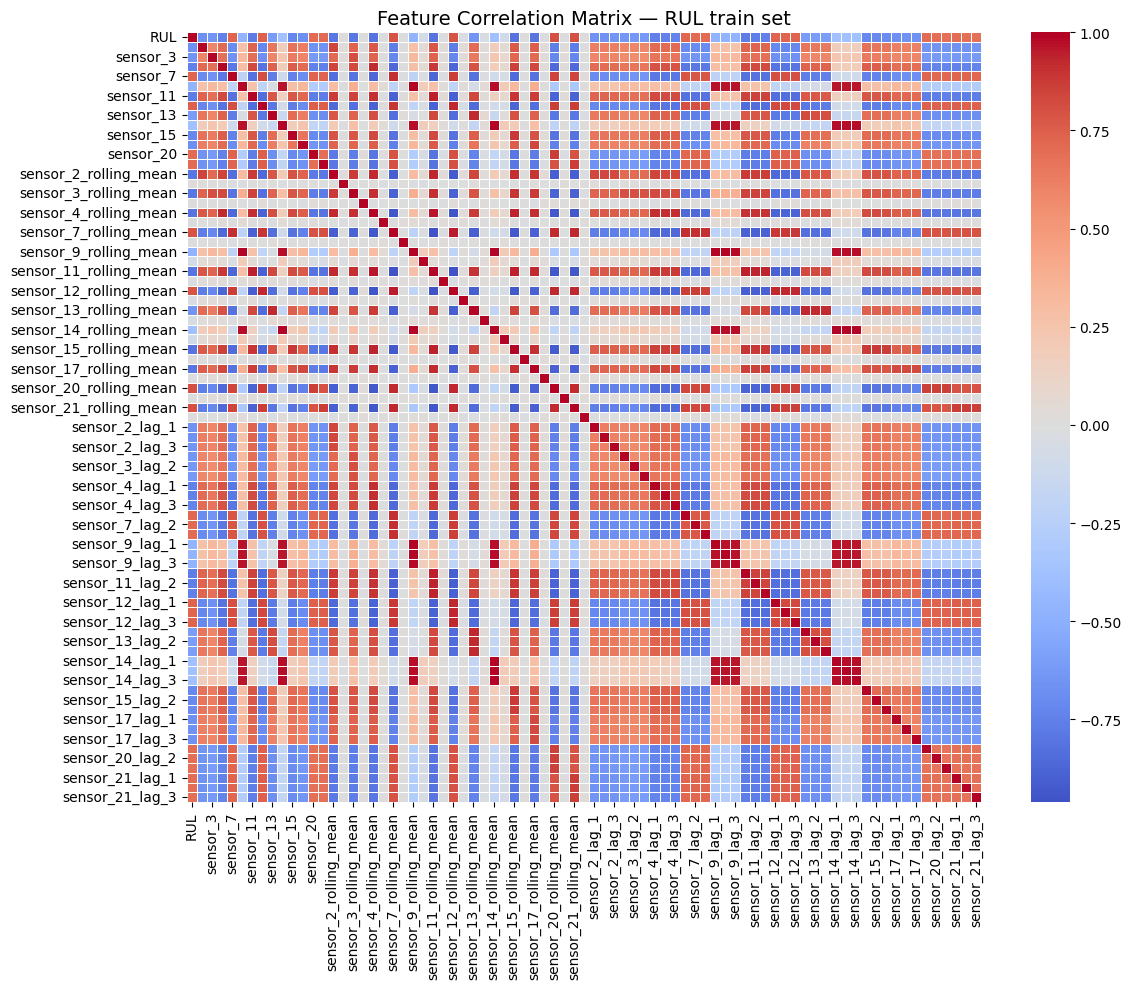

In [81]:
plt.figure(figsize=(12, 10))
corr_matrix = df_rul_train.drop(columns=["engine_id", "cycle"]).corr()

sns.heatmap(corr_matrix,
            cmap="coolwarm",
            center=0,
            annot=False,
            linewidths=0.5)

plt.title("Feature Correlation Matrix — RUL train set", fontsize=14)
plt.tight_layout()
plt.show()

**Observations:**

The heatmap is computed on the RUL training set only, to reflect the feature relationships seen during model training.
- **Original sensors + rolling mean**: highly correlated by construction — each sensor and its rolling mean capture the same underlying trend
- **Lag features**: strongly correlated with their original sensor and with each other, with correlation decreasing as lag distance increases
- **Rolling std**: largely decorrelated from all other features, capturing independent local volatility information
- **Cross-sensor correlations**: some sensor pairs show strong positive or negative correlation (e.g. sensor_3 and sensor_4), reflecting shared physical degradation mechanisms
- No perfectly redundant features are present — the feature set is validated and ready for modeling

## Save processed datasets

In [82]:
# RUL Forecasting
df_rul_train.to_parquet("../data/processed/rul_train.parquet", index=False)
df_rul_val.to_parquet("../data/processed/rul_val.parquet", index=False)

# Sensor Forecasting
df_forecast_train.to_parquet("../data/processed/forecast_train.parquet", index=False)
df_forecast_val.to_parquet("../data/processed/forecast_val.parquet", index=False)

# Anomaly Detection
df_anomaly_train.to_parquet("../data/processed/anomaly_healthy.parquet", index=False)
df_anomaly_val.to_parquet("../data/processed/anomaly_degraded.parquet", index=False)

In [83]:
print("Saved files:")
for f in os.listdir("../data/processed/"):
    print(f"  {f}")

Saved files:
  forecast_train.parquet
  forecast_val.parquet
  anomaly_healthy.parquet
  anomaly_degraded.parquet
  rul_train.parquet
  rul_val.parquet


## Summary

| Step | Input | Output |
|------|-------|--------|
| Sensor selection | 21 sensors | 13 sensors (8 dropped) |
| RUL cap | RUL 0–361 | RUL 0–125 |
| Train-Val split | 20231 rows | 3 task-specific raw splits |
| Normalization | raw values | zero mean, unit variance (fit on RUL train) |
| Rolling features | 13 sensors | +26 features |
| Lag features | 13 sensors | +39 features |
| Final dataset | 81 cols | 78 features + engine_id + cycle + RUL |
| RUL split | — | train: 16020, val: 4211 |
| Forecast split | — | train: 16068, val: 3763 |
| Anomaly split | — | healthy: 7732, degraded: 12100 |